Purpose: URL is Legitimate or Phising?

In [ ]:
#Import necessary libraries with aliases
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

In [ ]:
df = pd.read_csv("Phising_URL_ds_5percent_missing_train.csv")

EDA_arslanali

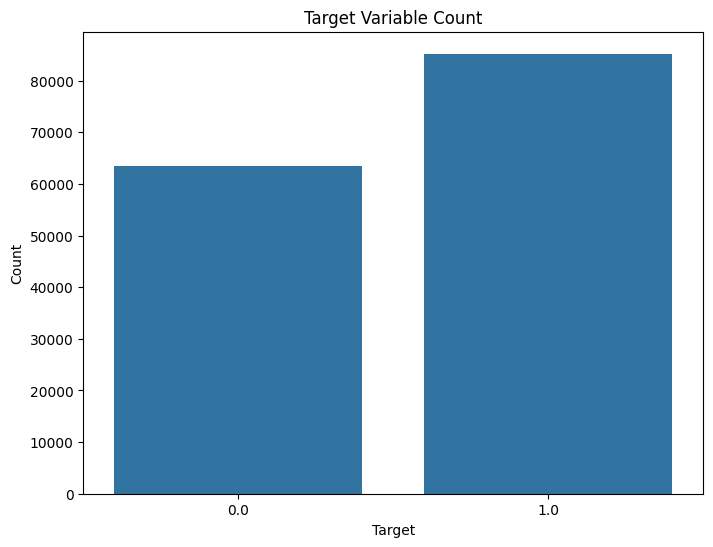

In [ ]:
#Looking number of target variables. This is important for our problem. In real life most of the URL's are legitimate. 
plt.figure(figsize=(8, 6))
sns.countplot(data=df, x=df["label"])
plt.xlabel('Target')
plt.ylabel('Count')
plt.title('Target Variable Count')
plt.show()

Comment: We see that the target variable counts are close to each other, a little bit imbalanced problem we deal with this. But as in real life scenario 0 (legitimate url) count is more than phising URL values. This dataset can gives us more information about phising urls. 

Comments: Strong correlation between features can be handle in feature enginerring part. Firstly, we want to look at closely on which features have effect on our target variable. We see this information on heatmap but we want to look closely.  

C:\Users\ASUS\AppData\Local\Temp\ipykernel_23980\2732559188.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)


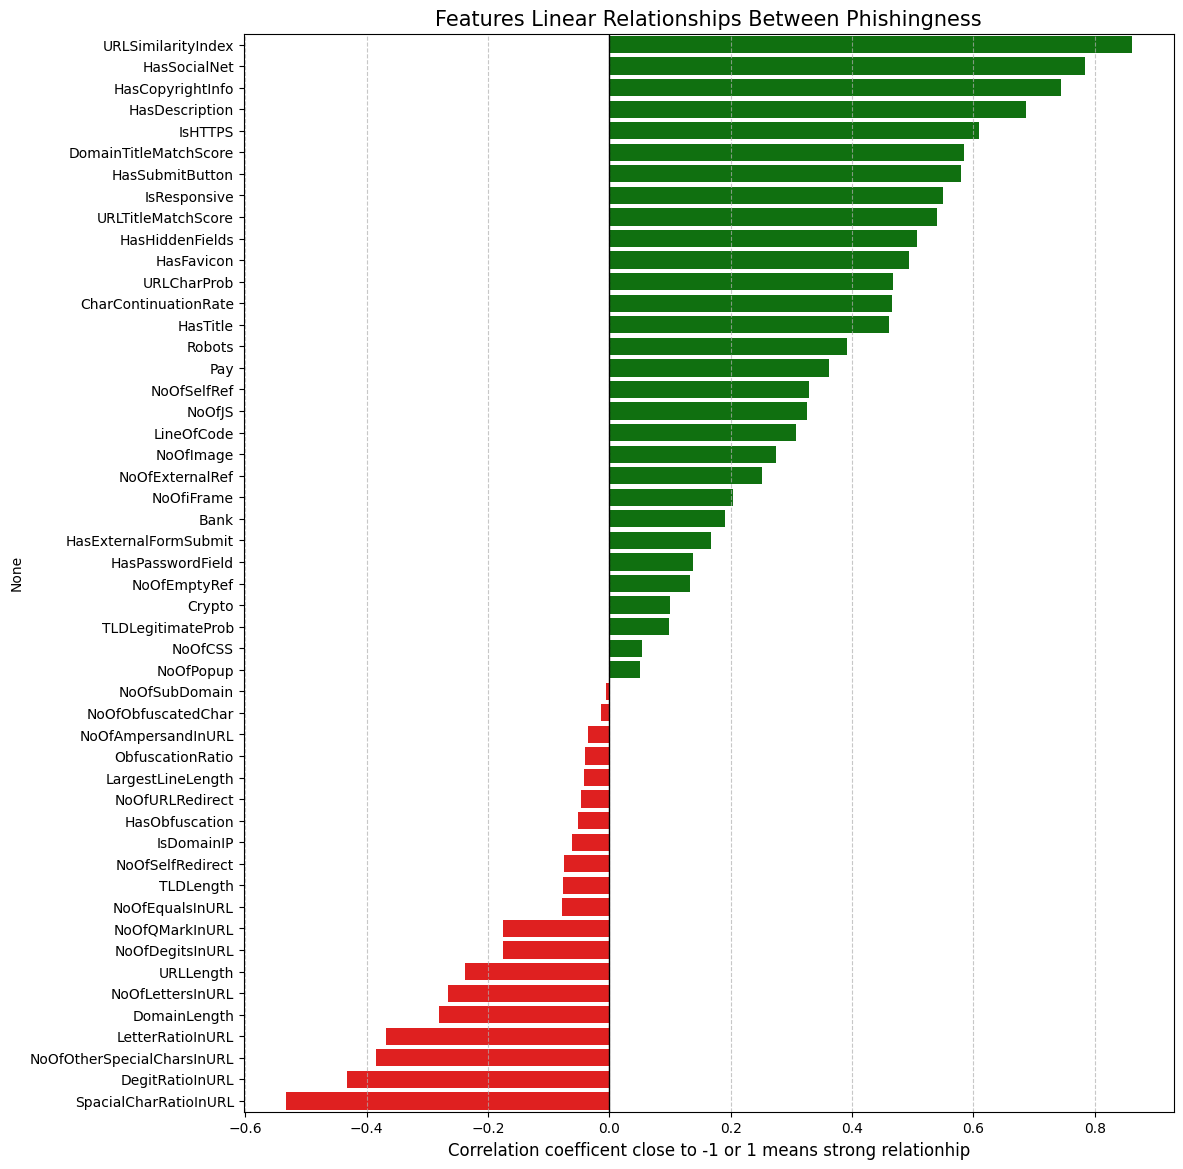

In [ ]:
target_corr = numeric_df.corr()['label'].sort_values(ascending=False)
target_corr = target_corr.drop('label')
plt.figure(figsize=(12, 14))
colors = ['green' if x > 0 else 'red' for x in target_corr.values] # (Green:Positive, Red: Negative)
sns.barplot(x=target_corr.values, y=target_corr.index, palette=colors)

plt.title('Features Linear Relationships Between Phishingness', fontsize=15)
plt.xlabel('Correlation coefficent close to -1 or 1 means strong relationhip', fontsize=12)
plt.axvline(0, color='black', linewidth=1) # Black line in the middle
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

Comment: Features that are close to 0 correlation coefficents indicates pottential features that we must deal with maybe we extract these from the model because they have not strong effect on target variable and adds complexity for our model. Strong relationships can be our focus features in the analysis. 

We examine that the some float and integer data types are binary variables. Firstly, we can seperate these variables and then we can see the the selected features which are seem more correlated with our target variable.

Question

"Bir alan adının (domain) 'www' önekiyle başlaması ile o sitenin Phishing (0) veya Legitimate (1) olması arasında istatistiksel olarak anlamlı bir ilişki var mıdır?"

In [ ]:
string_df = df.select_dtypes(include=['object']).columns
print(string_df)
print(df['Domain'].value_counts())

Comment: We examine that normally url domains starts with www, but phising sites may use this domain not inclued subdomain. We look this is true or not?

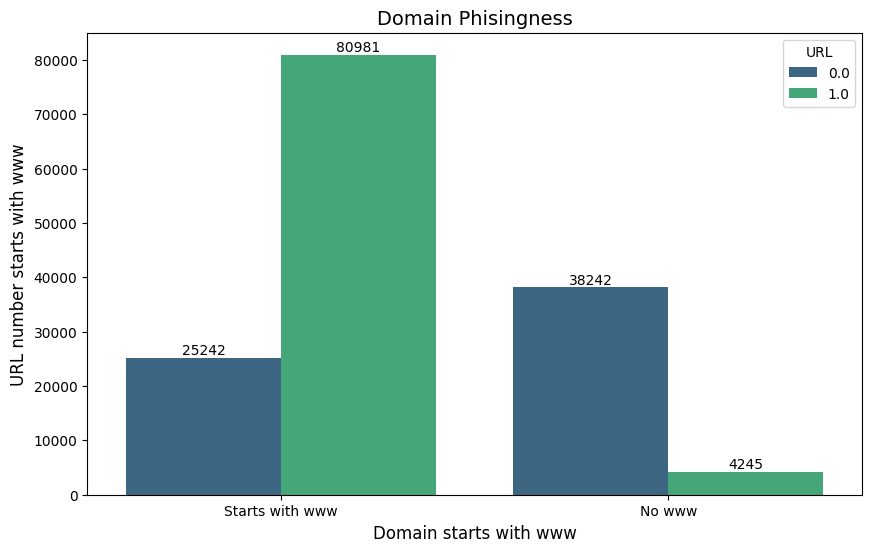

In [ ]:
#Creating new column domain starts with www
df['starts_with_www'] = df['Domain'].astype(str).str.startswith('www').map({True: 'Starts with www', False: 'No www'})
plt.figure(figsize=(10, 6))
ax = sns.countplot(data=df, x='starts_with_www', hue='label', palette='viridis')
plt.title('Domain Phisingness', fontsize=14)
plt.xlabel('Domain starts with www', fontsize=12)
plt.ylabel('URL number starts with www', fontsize=12)
plt.legend(title='URL')

for container in ax.containers:
    ax.bar_label(container)

plt.show()

In [ ]:
#Statistical Test-Contingency Table

contingency_table = pd.crosstab(df['starts_with_www'], df['label'])
print(contingency_table)

# Apply test
chi2, p, dof, expected = chi2_contingency(contingency_table)

print(f"\np-Value: {p:.5f}")
if p < 0.05:
    print("Result: Reject H0. There is meaningul relationship between two variable.")
    print("Comment: 'www' usage, gives informations about site is phishing or not.")
else:
    print("Result: Do no reject Ho. Relationhip is not meaningfull.")
    print("Comment: whether 'www' in domain is not meangul effect on phisingness.")

# Cleaning: Remove temporary columns
df.drop(columns=['starts_with_www'], inplace=True)

label              0.0    1.0
starts_with_www              
No www           38242   4245
Starts with www  25242  80981

p-Value: 0.00000
Result: Reject H0. There is meaningul relationship between two variable.
Comment: 'www' usage, gives informations about site is phishing or not.
